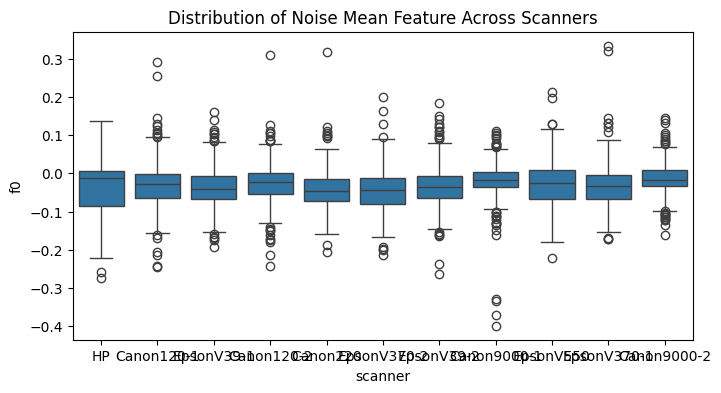

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

feature_df = pd.DataFrame(X, columns=[f"f{i}" for i in range(len(X[0]))])
feature_df["scanner"] = y

plt.figure(figsize=(8,4))
sns.boxplot(x="scanner", y="f0", data=feature_df)
plt.title("Distribution of Noise Mean Feature Across Scanners")
plt.show()


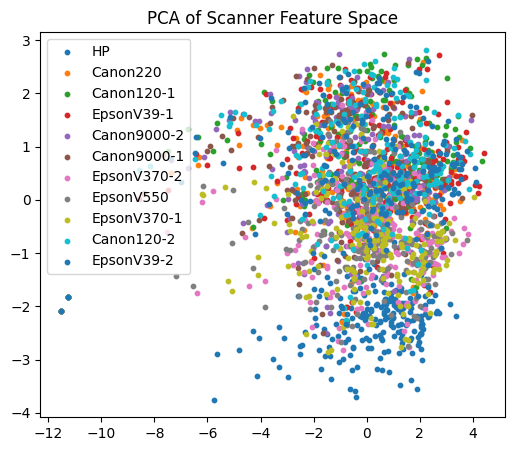

In [13]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X_scaled_vis = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_vis)

plt.figure(figsize=(6,5))
for scanner in set(y):
    idx = [i for i, s in enumerate(y) if s == scanner]
    plt.scatter(X_pca[idx,0], X_pca[idx,1], label=scanner, s=10)

plt.legend()
plt.title("PCA of Scanner Feature Space")
plt.show()


In [22]:
!pip install scikit-image scipy


In [23]:
import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
import pywt


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from skimage.feature import local_binary_pattern
from scipy.stats import skew, kurtosis
from google.colab import drive
drive.mount('/content/drive')
csv_path = "/content/drive/MyDrive/AI_TraceFinder_preprocessed/merged_labels.csv"
df = pd.read_csv(csv_path)

# Use ONLY FlatField images
df = df[df["Dataset"] == "FlatField"].reset_index(drop=True)

print("Total flat-field images:", len(df))
df.head()
train_rows = []
test_rows = []

for scanner, group in df.groupby("Scanner_Model"):
    group = group.sample(frac=1, random_state=42)  # shuffle
    test_rows.append(group.iloc[0])       # 1 image for test
    train_rows.append(group.iloc[1:])     # rest for train

train_df = pd.concat(train_rows).reset_index(drop=True)
test_df = pd.DataFrame(test_rows).reset_index(drop=True)

print("Train images:", len(train_df))
print("Test images:", len(test_df))
def extract_patches(img, patch_size=24, stride=4):
    patches = []
    h, w = img.shape
    for y in range(0, h - patch_size + 1, stride):
        for x in range(0, w - patch_size + 1, stride):
            patch = img[y:y+patch_size, x:x+patch_size]
            patches.append(patch)
    return patches
def extract_features(patch):
    features = []

    # ---------- Noise statistics ----------
    mean = np.mean(patch)
    var = np.var(patch)
    sk = skew(patch.flatten())
    kurt = kurtosis(patch.flatten())
    features.extend([mean, var, sk, kurt])

    # ---------- FFT features ----------
    fft = np.fft.fft2(patch)
    fft_shift = np.fft.fftshift(fft)
    mag = np.abs(fft_shift)

    features.append(np.mean(mag))
    features.append(np.std(mag))
    features.append(np.sum(mag))

    # Radial frequency energy
    h, w = mag.shape
    cy, cx = h // 2, w // 2
    y, x = np.ogrid[:h, :w]
    r = np.sqrt((x - cx)**2 + (y - cy)**2)

    for band in [8, 16, 24]:
        features.append(np.mean(mag[r < band]))

    # ---------- LBP texture ----------
    lbp = local_binary_pattern(patch, P=8, R=1, method='uniform')
    hist, _ = np.histogram(lbp, bins=10, range=(0, 10), density=True)
    features.extend(hist)
    coeffs = pywt.dwt2(patch, 'haar')
    LL, (LH, HL, HH) = coeffs

    features.extend([
      np.mean(LL), np.var(LL),
      np.mean(LH), np.var(LH),
      np.mean(HL), np.var(HL),
      np.mean(HH), np.var(HH)
])

    return features
def build_dataset(df):
    X, y = [], []

    for _, row in tqdm(df.iterrows(), total=len(df)):
        img = cv2.imread(row["Path"], cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        patches = extract_patches(img)

        for patch in patches:
            feats = extract_features(patch)
            X.append(feats)
            y.append(row["Scanner_Model"])

    return np.array(X), np.array(y)
X_train, y_train = build_dataset(train_df)
X_test, y_test = build_dataset(test_df)

print("Train patches:", X_train.shape)
print("Test patches:", X_test.shape)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
rf = RandomForestClassifier(
    n_estimators=600,
    max_depth=30,
    min_samples_leaf=1,
    max_features="sqrt",
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train_enc)
from collections import Counter
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Image-level prediction with majority voting
def image_level_prediction(model, scaler, le, df, patch_size=32, stride=8):
    y_true, y_pred = [], []

    for _, row in df.iterrows():
        img = cv2.imread(row["Path"], cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        # Extract patches
        patches = []
        h, w = img.shape
        for y in range(0, h - patch_size + 1, stride):
            for x in range(0, w - patch_size + 1, stride):
                patch = img[y:y+patch_size, x:x+patch_size]
                patches.append(patch)

        # Extract features for each patch
        feats = [extract_features(p) for p in patches]
        feats = scaler.transform(feats)

        # Predict patches
        patch_preds = model.predict(feats)

        # Majority vote for the image
        majority_class = Counter(patch_preds).most_common(1)[0][0]

        # Store results
        y_true.append(le.transform([row["Scanner_Model"]])[0])
        y_pred.append(majority_class)

    return y_true, y_pred

# Run image-level predictions
y_true_img, y_pred_img = image_level_prediction(rf, scaler, le, test_df)

# Accuracy
acc = accuracy_score(y_true_img, y_pred_img)
print("Image-level Accuracy:", acc)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_true_img, y_pred_img, target_names=le.classes_))

# Confusion Matrix
print("Confusion Matrix:\n")
cm = confusion_matrix(y_true_img, y_pred_img)
print(cm)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Total flat-field images: 22
Train images: 11
Test images: 11


  0%|          | 0/11 [00:00<?, ?it/s]/tmp/ipython-input-1639120059.py:53: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  sk = skew(patch.flatten())
/tmp/ipython-input-1639120059.py:54: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  kurt = kurtosis(patch.flatten())
100%|██████████| 11/11 [02:08<00:00, 11.65s/it]


Train patches: (38291, 28)
Test patches: (38291, 28)


/tmp/ipython-input-1639120059.py:53: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  sk = skew(patch.flatten())
/tmp/ipython-input-1639120059.py:54: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  kurt = kurtosis(patch.flatten())
/tmp/ipython-input-1639120059.py:53: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  sk = skew(patch.flatten())
/tmp/ipython-input-1639120059.py:54: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  kurt = kurtosis(patch.flatten())
/tmp/ipython-input-1639120059.py:53: Run

Image-level Accuracy: 0.09090909090909091

Classification Report:

              precision    recall  f1-score   support

  Canon120-1       0.00      0.00      0.00         1
  Canon120-2       0.00      0.00      0.00         1
    Canon220       0.00      0.00      0.00         1
 Canon9000-1       0.00      0.00      0.00         1
 Canon9000-2       0.09      1.00      0.17         1
 EpsonV370-1       0.00      0.00      0.00         1
 EpsonV370-2       0.00      0.00      0.00         1
  EpsonV39-1       0.00      0.00      0.00         1
  EpsonV39-2       0.00      0.00      0.00         1
   EpsonV550       0.00      0.00      0.00         1
          HP       0.00      0.00      0.00         1

    accuracy                           0.09        11
   macro avg       0.01      0.09      0.02        11
weighted avg       0.01      0.09      0.02        11

Confusion Matrix:

[[0 0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0]
 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
